In [1]:
#Import Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the dataset
df = pd.read_csv(r"C:\Users\simpi\Downloads\CIC-IDS2017-Dataset\CIC-IDS2017-Dataset\Infiltration-Thursday-no-metadata.parquet.csv")

In [3]:
df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,166,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,83,1,2,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,17,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,17,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.6,2123197.5,4822992,95,9463033.0,2657728.0,13600000,5700287,Benign


In [4]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

In [5]:
# Verify updated column names
print(df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [6]:
# Count missing values in each column
missing_values = df.isnull().sum()

In [8]:
# Count infinite values
np.isinf(df.select_dtypes(include=[np.number])).sum().sum()

np.int64(0)

In [9]:
# Remove rows containing missing values
df.dropna(inplace=True)

In [10]:
# Count and display the number of samples in each class
class_counts = df['Label'].value_counts()
print(class_counts)

Label
Benign          207594
Infiltration        36
Name: count, dtype: int64


In [11]:
# Calculating and displaying the  percentage of each class
class_percentage = (df['Label'].value_counts(normalize=True) * 100).round(4)
print(class_percentage)

Label
Benign          99.9827
Infiltration     0.0173
Name: proportion, dtype: float64


C:\Users\simpi\AppData\Local\Temp\ipykernel_15128\4045684084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


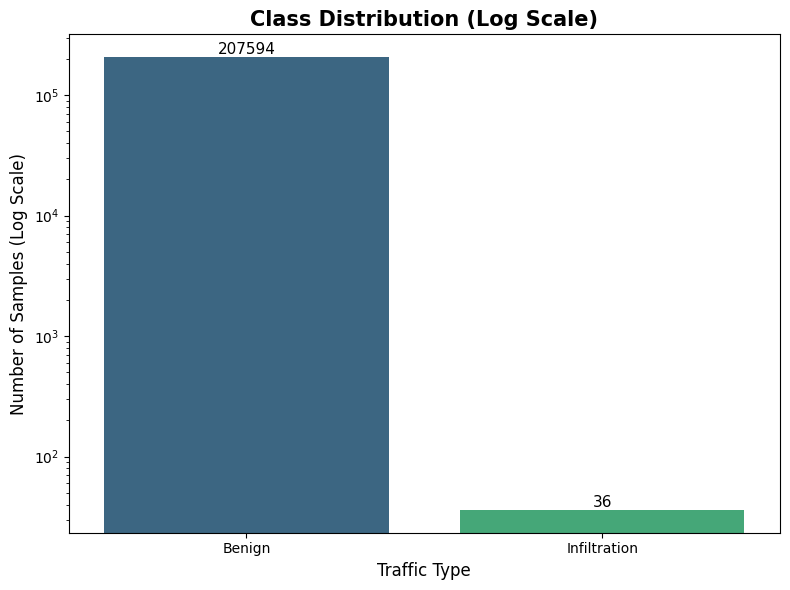

In [12]:
#Class Distribution
plt.figure(figsize=(8,6))
ax = sns.countplot(
    x='Label',
    data=df,
    palette='viridis'
)
plt.yscale('log')
plt.title('Class Distribution (Log Scale)', fontsize=15, fontweight='bold')
plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Number of Samples (Log Scale)', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11)

plt.tight_layout()
plt.show()

In [13]:
# Compare packet length statistics by traffic type
packet_stats = df.groupby('Label')[['Fwd Packet Length Max', 'Fwd Packet Length Mean']].describe()
packet_stats

Fwd Packet Length Max                                       \
                             count         mean         std  min    25%   
Label                                                                     
Benign                    207594.0   192.213311  502.358688  0.0   29.0   
Infiltration                  36.0  1010.305556  493.780913  0.0  705.0   

                                      Fwd Packet Length Mean              \
                 50%     75%      max                  count        mean   
Label                                                                      
Benign          42.0    84.0  23360.0               207594.0   55.329021   
Infiltration  1226.0  1320.5   1460.0                   36.0  296.866603   

                                                                             
                     std  min         25%        50%         75%        max  
Label                                                                        
Benign        135.854558  0.0   14.333333   38.00000   51.000000  4317.0977  
Infiltration  184.075518  0.0  210.439290  289.26854  386.822693   920.7500

C:\Users\simpi\AppData\Local\Temp\ipykernel_15128\2071114168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


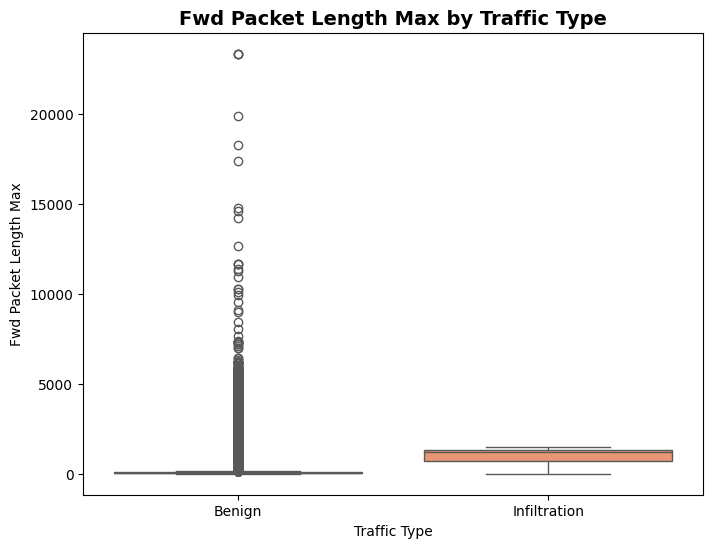

In [14]:
#Fwd Packet Lengrth Max
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='Label',
    y='Fwd Packet Length Max',
    palette='Set2'
)
plt.title('Fwd Packet Length Max by Traffic Type', fontsize=14, fontweight='bold')
plt.xlabel('Traffic Type')
plt.ylabel('Fwd Packet Length Max')

plt.show()

C:\Users\simpi\AppData\Local\Temp\ipykernel_15128\3613805709.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


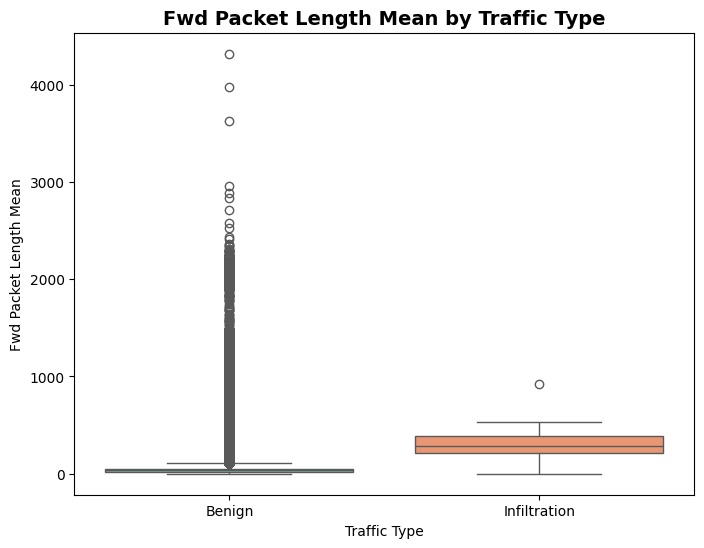

In [15]:
#Fwd Packet Length Mean
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='Label',
    y='Fwd Packet Length Mean',
    palette='Set2'
)
plt.title('Fwd Packet Length Mean by Traffic Type', fontsize=14, fontweight='bold')
plt.xlabel('Traffic Type')
plt.ylabel('Fwd Packet Length Mean')

plt.show()

C:\Users\simpi\AppData\Local\Temp\ipykernel_15128\1656606360.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


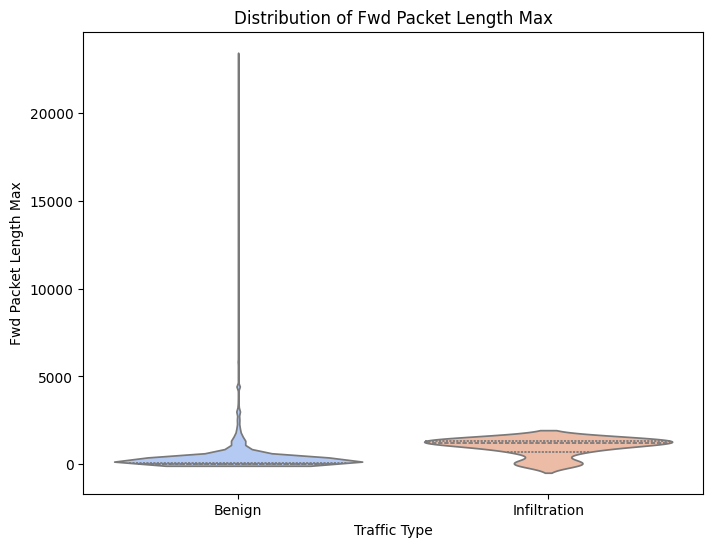

In [16]:
#Violin Plot 
#Fwd Packet Length Max
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df,
    x='Label',
    y='Fwd Packet Length Max',
    palette='coolwarm',
    inner='quartile'
)
plt.title('Distribution of Fwd Packet Length Max')
plt.xlabel('Traffic Type')
plt.ylabel('Fwd Packet Length Max')

plt.show()

C:\Users\simpi\AppData\Local\Temp\ipykernel_15128\2823393764.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


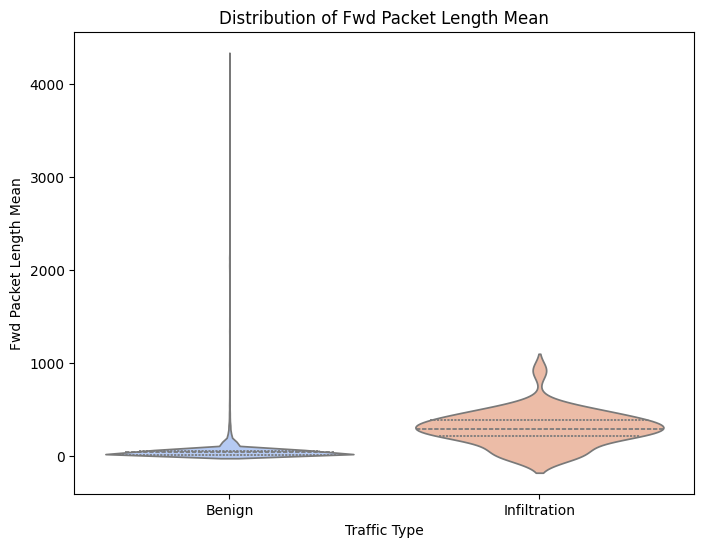

In [17]:
#Fwd Packet Length Mean(Violin Plot)
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x='Label',
    y='Fwd Packet Length Mean',
    palette='coolwarm',
    inner='quartile'
)

plt.title('Distribution of Fwd Packet Length Mean')
plt.xlabel('Traffic Type')
plt.ylabel('Fwd Packet Length Mean')

plt.show()

In [18]:
#Visualizing Network Pacing and Delays (Idle Times)
# Compare Idle Mean and Flow Duration for each traffic type
idle_stats = df.groupby('Label')[['Idle Mean', 'Flow Duration']].describe()
idle_stats

Idle Mean                                                \
                 count          mean           std  min          25%   
Label                                                                  
Benign        207594.0  3.620722e+06  1.243821e+07  0.0        0.000   
Infiltration      36.0  2.661751e+07  2.814969e+07  0.0  6107990.625   

                                                  Flow Duration                \
                     50%         75%          max         count          mean   
Label                                                                           
Benign               0.0         0.0  120000000.0      207594.0  1.244006e+07   
Infiltration  18950000.0  33925000.0  104000000.0          36.0  7.840772e+07   

                                                                         \
                       std   min          25%         50%           75%   
Label                                                                     
Benign        3.176044e+07  -2.0       212.00     38802.5  1.106481e+06   
Infiltration  4.039664e+07  20.0  54516598.25  93188869.0  1.167758e+08   

                           
                      max  
Label                      
Benign        119999936.0  
Infiltration  119995180.0

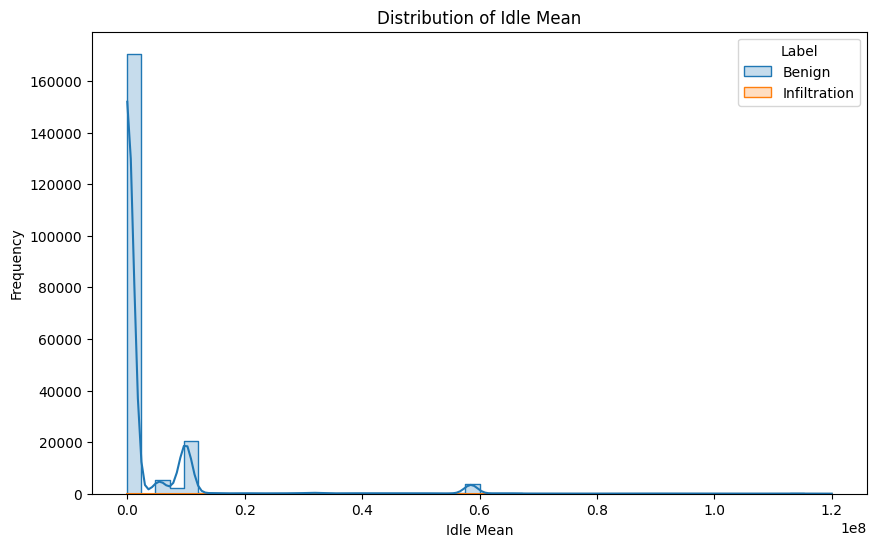

In [19]:
#Distribution of Ideal Mean
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='Idle Mean',
    hue='Label',
    bins=50,
    kde=True,
    element='step'
)
plt.title('Distribution of Idle Mean')
plt.xlabel('Idle Mean')
plt.ylabel('Frequency')

plt.show()

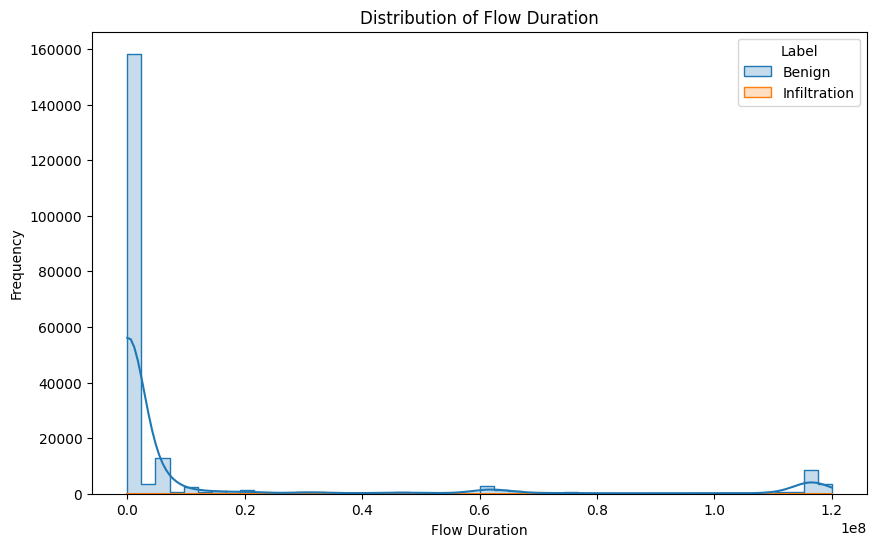

In [20]:
#Distribution of flow duration
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='Flow Duration',
    hue='Label',
    bins=50,
    kde=True,
    element='step'
)
plt.title('Distribution of Flow Duration')
plt.xlabel('Flow Duration')
plt.ylabel('Frequency')

plt.show()

C:\Users\simpi\AppData\Local\Temp\ipykernel_15128\3903465797.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


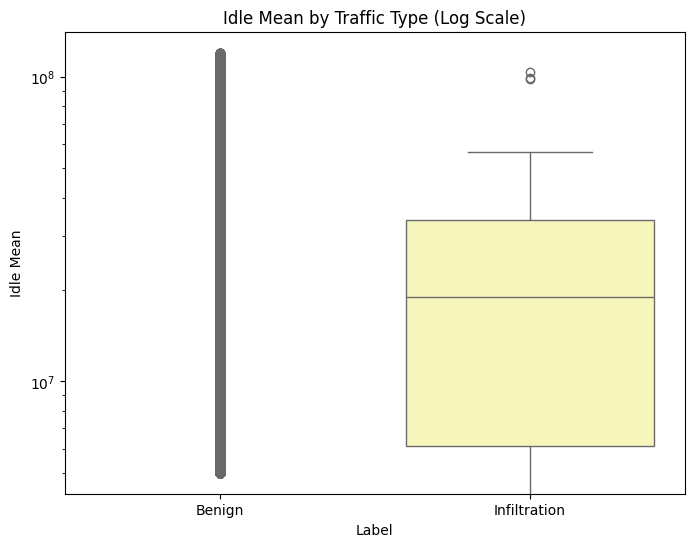

In [21]:
#Box plot comparision(Ideal Mean)
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='Label',
    y='Idle Mean',
    palette='Set3'
)
plt.yscale('log')
plt.title('Idle Mean by Traffic Type (Log Scale)')
plt.show()

C:\Users\simpi\AppData\Local\Temp\ipykernel_15128\2501398909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


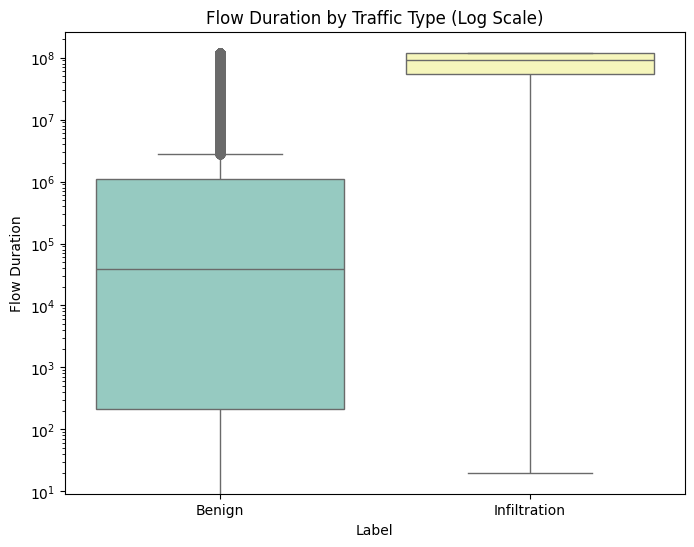

In [22]:
#Flow duration(Box Plot)
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='Label',
    y='Flow Duration',
    palette='Set3'
)
plt.yscale('log')
plt.title('Flow Duration by Traffic Type (Log Scale)')
plt.show()

In [23]:
#Feature Engineering 
#Inactivity Index 
df['Inactivity_Index'] = df['Idle Mean'] / (df['Active Mean'] + 1e-6)
df[['Idle Mean', 'Active Mean', 'Inactivity_Index']].head()

,Idle Mean,Active Mean,Inactivity_Index
0,0.0,0.0,0.000000
1,0.0,0.0,0.000000
2,0.0,0.0,0.000000
3,0.0,0.0,0.000000
4,9463033.0,1753752.6,5.395877


In [26]:
#Payload Sparsity
df['Total_Bytes'] = (
    df['Fwd Packets Length Total'] +
    df['Bwd Packets Length Total']
)
df['Payload_Sparsity'] = (
    df['Total_Bytes'] /
    (df['Flow Duration'] + 1e-6)
)
df[['Total_Bytes', 'Flow Duration', 'Payload_Sparsity']].head()

,Total_Bytes,Flow Duration,Payload_Sparsity
0,0,166,0.000000
1,0,83,0.000000
2,96,99947,0.000961
3,96,37017,0.002593
4,0,111161336,0.000000


In [27]:
# Log Transformation
df['Log_Flow_Duration'] = np.log1p(df['Flow Duration'])
df['Log_Idle_Mean'] = np.log1p(df['Idle Mean'])
df[['Log_Flow_Duration', 'Log_Idle_Mean']].head()

c:\Users\simpi\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\simpi\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Log_Flow_Duration,Log_Idle_Mean
0,5.117994,0.000000
1,4.430817,0.000000
2,11.512405,0.000000
3,10.519160,0.000000
4,18.526493,16.062904


In [28]:
# Display the engineered features
new_features = [
    'Inactivity_Index',
    'Total_Bytes',
    'Payload_Sparsity',
    'Log_Flow_Duration',
    'Log_Idle_Mean'
]

df[new_features].head()

,Inactivity_Index,Total_Bytes,Payload_Sparsity,Log_Flow_Duration,Log_Idle_Mean
0,0.000000,0,0.000000,5.117994,0.000000
1,0.000000,0,0.000000,4.430817,0.000000
2,0.000000,96,0.000961,11.512405,0.000000
3,0.000000,96,0.002593,10.519160,0.000000
4,5.395877,0,0.000000,18.526493,16.062904


In [29]:
#Corelation Analysis and Feature Pruning 
numeric_df = df.select_dtypes(include=['number'])
print("Total Numerical Features:", numeric_df.shape[1])

Total Numerical Features: 82


In [30]:
corr_matrix = numeric_df.corr()
corr_matrix.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inactivity_Index,Total_Bytes,Payload_Sparsity,Log_Flow_Duration,Log_Idle_Mean
Protocol,1.000000,-0.307333,-0.064347,-0.047276,-0.021221,-0.035350,-0.278362,0.574126,-0.078243,-0.331690,...,-0.085685,-0.120074,-0.062783,-0.124206,-0.110653,-0.017327,-0.037844,0.007173,-0.232865,-0.348144
Flow Duration,-0.307333,1.000000,0.112259,0.086115,0.032799,0.055463,0.364995,-0.197052,0.082219,0.312729,...,0.101043,0.642341,0.187102,0.646212,0.617704,0.022258,0.059309,-0.027231,0.640067,0.810009
Total Fwd Packets,-0.064347,0.112259,1.000000,0.949990,0.323938,0.920844,0.081143,-0.036884,0.028808,0.047003,...,0.095282,0.063214,0.034063,0.066166,0.058717,-0.000919,0.954723,-0.000585,0.095995,0.096322
Total Backward Packets,-0.047276,0.086115,0.949990,1.000000,0.147137,0.959045,0.064315,-0.030605,0.009461,0.032045,...,0.071988,0.053278,0.027292,0.055348,0.049825,-0.001055,0.968492,-0.002092,0.075029,0.074793
Fwd Packets Length Total,-0.021221,0.032799,0.323938,0.147137,1.000000,0.012686,0.098061,0.013127,0.134143,0.080945,...,0.023724,0.012055,0.021544,0.015317,0.009320,-0.000333,0.148365,0.004438,0.024697,0.024208


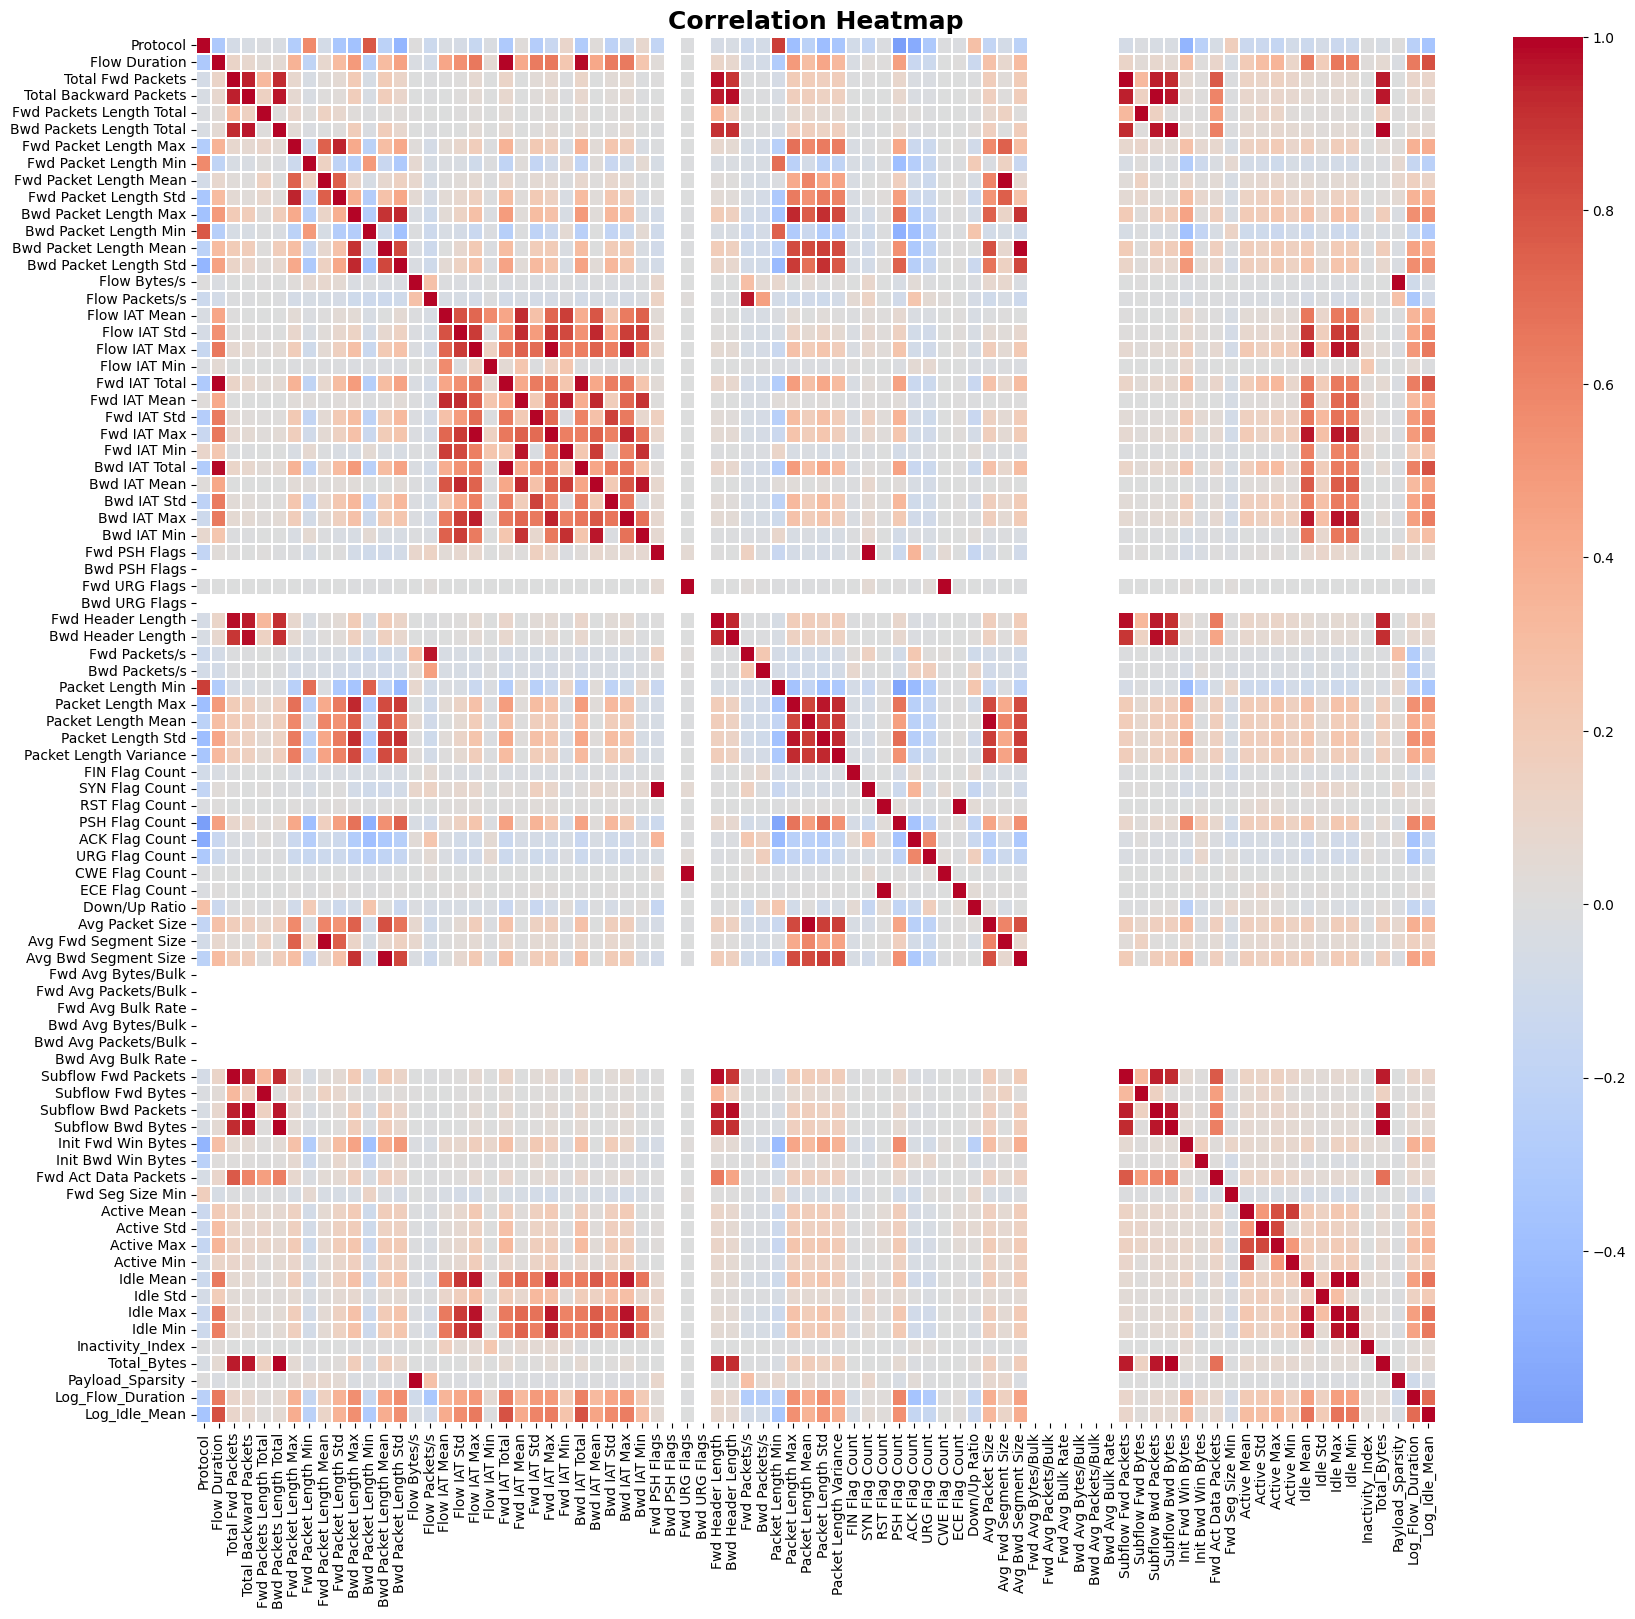

In [31]:
plt.figure(figsize=(20,18))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.2
)
plt.title("Correlation Heatmap", fontsize=18, fontweight='bold')
plt.show()